In [ ]:
!pip install git+https://github.com/songyanzhu/geoxai.git -U --quiet

from scitbx import google
root = google.mount_drive()
root_proj = root.joinpath("workspace/project_data/gapfilling")

from geoxai.easy_import import *
from geoxai.regress2 import regress2
from geoxai.remotesensing import *
from geoxai import climate
from geoxai import pipelines

from geoxai import remotesensing
from geoxai import photosynthesis, respiration, evapotranspiration
from geoxai.meteo import saturation_vapor_pressure, specific_humidity2vapor_pressure

warnings.simplefilter('ignore')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.8 MB/s eta 0:00:00
Mounted at /content/drive
No module named 'rasterio', so `scitbx` is installing it for you...
No module named 'rioxarray', so `scitbx` is installing it for you...


In [ ]:
def sample_continuous_subsets(df, subset_plan, time_col = None, min_valid_ratio = 0.66, max_attempts = 50, seed = 42):
    """
    Randomly selects continuous, non-overlapping subsets from a time series DataFrame,
    ensuring each subset:
        - Has a specific length as defined in `subset_plan`.
        - Appears a specific number of times, avoiding overlaps.
        - Has at least `min_valid_ratio` valid (non-NaN) values.

    Args:
        df (pd.DataFrame): Input time series DataFrame.
        subset_plan (dict): Dictionary {subset_length: count}.
        time_col (str): Optional column name to sort by if time-based ordering is required.
        min_valid_ratio (float): Minimum fraction of non-NaN values required in a subset.
        max_attempts (int): Maximum retries to find a valid subset.
        seed (int): Random seed for reproducibility.

    Returns:
        list of pd.DataFrame: A list of sampled, non-overlapping DataFrame subsets.
    """
    np.random.seed(seed)
    if time_col:
        df = df.sort_values(by=time_col).reset_index(drop=True)  # Ensure time-ordering
    else:
        df = df.sort_index()  # Sort by index if no time column is provided

    subsets = []
    selected_ranges = []  # Track used (start_idx, end_idx) ranges to prevent overlaps
    max_index = len(df) - 1

    for length, count in subset_plan.items():
        for _ in range(count):
            valid_subset_found = False
            attempts = 0

            while not valid_subset_found and attempts < max_attempts:
                if max_index - length + 1 <= 0:  # Ensure there's space for selection
                    break

                start_idx = np.random.randint(0, max_index - length + 1)
                end_idx = start_idx + length - 1

                # Ensure no overlap
                if any(start <= end_idx and end >= start_idx for start, end in selected_ranges):
                    attempts += 1
                    continue  # Retry with a new selection

                subset = df.iloc[start_idx : start_idx + length]  # Extract subset

                # Check valid (non-NaN) ratio
                valid_ratio = subset.notna().mean().mean()
                if valid_ratio >= min_valid_ratio:
                    subsets.append(subset)
                    selected_ranges.append((start_idx, end_idx))  # Mark range as used
                    valid_subset_found = True

                attempts += 1

    return subsets

# # Example Usage
# data = {
#     "timestamp": pd.date_range(start="2023-01-01", periods=100, freq="D"),
#     "value": np.random.randn(100)
# }

# # Introduce NaNs randomly
# nan_indices = np.random.choice(100, size=30, replace=False)  # Randomly pick 30 indices
# data["value"][nan_indices] = np.nan

# df = pd.DataFrame(data)

# # Define specific subset lengths and counts
# subset_plan = {5: 4, 10: 2, 15: 1}  # 4 subsets of length 5, 2 of 10, and 1 of 15
# sampled_subsets = sample_continuous_subsets(df, subset_plan, time_col="timestamp")

# # Print results
# for i, subset in enumerate(sampled_subsets):
#     print(f"Subset {i+1} (length={len(subset)}):\n", subset, "\n")


In [ ]:
from xgboost import XGBRegressor

def gap_filling_training(X_train, y_train, n_models = 100, frac_sample = 0.8):
    base_params_xgb = {
        "objective": "reg:squarederror",
        'seed': 0,
        "random_state": 0,
    }
    params_xgb = deepcopy(base_params_xgb)
    # dropout-like regularization
    params_xgb.update({
        "subsample": 0.8,  # Use 80% of the data for each tree
        "colsample_bytree": 0.8,  # Use 80% of the features for each tree
    })

    models = []
    for i in tqdm(range(n_models)):
        # Create a bootstrapped dataset
        y_resampled = y_train.copy().sample(frac = frac_sample, random_state = i)
        X_resampled = X_train.copy().loc[y_resampled.index]
        # print(y_resampled.sort_index().index[0], y_resampled.sort_index().index[-1])

        # Train the XGBoost model
        params_xgb.update({'random_state': i})
        model = XGBRegressor(**params_xgb)
        model.fit(X_resampled, y_resampled)
        models.append(model)
    return models

def gap_filling_validation(models, art_gaps, Xs, X_names):
    y_test_all = []
    y_pred_all = []
    for gap in art_gaps:
        y_pred = []
        for i in range(len(models)):
            model = models[i]
            X_test = Xs.loc[gap.index, X_names]
            y_pred_t = model.predict(X_test)
            y_pred_t = pd.DataFrame(y_pred_t, index = gap.index, columns = ['pred_' + str(i).zfill(2)])
            y_pred.append(y_pred_t)
        y_pred = pd.concat(y_pred, axis = 1)
        y_pred_all.append(y_pred)
        y_test_all.append(gap)

    y_pred_all = pd.concat(y_pred_all, axis = 0)
    y_test_all = pd.concat(y_test_all, axis = 0)

    dfo = pd.concat([y_test_all, y_pred_all.mean(axis = 1).rename('pred')], axis = 1)
    eval_res = pipelines.get_metrics(dfo, truth = 'truth', pred = 'pred', return_dict = True)
    eval_res['MEAN'] = dfo['truth'].mean()
    # eval_res['UNC'] = y_pred_all.std(axis = 1).mean()
    return eval_res

In [ ]:
filling_variable = 'LE'

df_eval_res = []
paths = list(root_proj.joinpath('Flux_data').glob('*.csv'))
for cnt, p in enumerate(paths):
    site = p.stem.split('_DATA')[0]
    # if site != 'BJ_BEF': continue
    print(f"............{cnt + 1} of {len(paths)}: {site}............")
    df_ec = pd.read_csv(p, encoding='unicode_escape', index_col = 0)
    try:
        df_ec.index = pd.to_datetime(df_ec.index, format = '%Y-%m-%d %H:%M:%S')
    except Exception as e:
        df_ec.index = pd.to_datetime(df_ec.index, format = '%d/%m/%Y %H:%M')

    if 'c_co2_flux_µmol.m-2.s-1' in df_ec.columns: df_ec = df_ec.rename(columns = {'c_co2_flux_µmol.m-2.s-1': 'co2_flux_µmol.m-2.s-1'})
    if 'co2_flux_4.5m_µmol.m-2.s-1' in df_ec.columns: df_ec = df_ec.rename(columns = {'co2_flux_4.5m_µmol.m-2.s-1': 'co2_flux_µmol.m-2.s-1'})
    cflux_name = 'co2_flux_µmol.m-2.s-1'
    if cflux_name in df_ec.columns:
        mask = (df_ec[cflux_name] > 100) | (df_ec[cflux_name] < -100)
        df_ec.loc[mask, cflux_name] = np.nan
    hflux_name = 'sensible_heat_W/m²'
    if not hflux_name in df_ec.columns:
        if ('sensible_heat_20m_W/m²' in df_ec.columns) & ('sensible_heat_4.5m_W/m²' in df_ec.columns):
            df_ec[hflux_name] = (df_ec['sensible_heat_20m_W/m²'] + df_ec['sensible_heat_4.5m_W/m²']) / 2
        elif ('sensible_heat_4.5m_W/m²' in df_ec.columns):
            df_ec = df_ec.rename(columns = {'sensible_heat_4.5m_W/m²': hflux_name})
        elif ('sensible_heat_20m_W/m²' in df_ec.columns):
            df_ec = df_ec.rename(columns = {'sensible_heat_20m_W/m²': hflux_name})
        else:
            pass
    if hflux_name in df_ec.columns:
        mask = df_ec[hflux_name] < 0
        df_ec.loc[mask, hflux_name] = np.nan
    wflux_name = 'latent_heat_W/m²'
    if not wflux_name in df_ec.columns:
        if ('latent_heat_20m_W/m²' in df_ec.columns) & ('latent_heat_4.5m_W/m²' in df_ec.columns):
            df_ec[wflux_name] = (df_ec['latent_heat_20m_W/m²'] + df_ec['latent_heat_4.5m_W/m²']) / 2
        elif ('latent_heat_4.5m_W/m²' in df_ec.columns):
            df_ec = df_ec.rename(columns = {'latent_heat_4.5m_W/m²': wflux_name})
        elif ('latent_heat_20m_W/m²' in df_ec.columns):
            df_ec = df_ec.rename(columns = {'latent_heat_20m_W/m²': wflux_name})
        else:
            pass

    # --------------------------------------------------------------------------
    df_ec['month'] = df_ec.index.month
    df_ec['day'] = df_ec.index.day
    df_ec['hour'] = df_ec.index.hour

    # ==========================================================================

    X_names = ['ERA5_Temp_C', 'ERA5_SSR_W.M2', 'ERA5_LWR_W.M2', 'ERA5_Wind_Speed_m.s', 'ERA5_Precip_mm', 'VPD_hPa', 'month', 'day', 'hour']
    if filling_variable == 'CO2':
        y_name = ['co2_flux_µmol.m-2.s-1']; savefolder = root_proj.joinpath('output_FC')
    elif filling_variable == 'H':
        y_name = ['sensible_heat_W/m²']; savefolder = root_proj.joinpath('output_H')
    elif filling_variable == 'LE':
        y_name = ['latent_heat_W/m²']; savefolder = root_proj.joinpath('output_LE')
    else:
        raise Exception('Unknown filling variable')
    if not y_name[0] in df_ec.columns: continue

    subset_plan = {48: 20, 48 * 7: 10, 48 * 30: 1} # short gaps (24 h, 20% of total gaps), long gaps (7-day, 30% of total gaps) and very-long gaps (30-day, 50% of total gaps).

    Xs = df_ec[X_names]
    ys = df_ec[y_name]

    for min_valid_ratio in [0.66, 0.5, 0.45, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
        art_gaps = sample_continuous_subsets(ys, subset_plan, min_valid_ratio = min_valid_ratio)
        if art_gaps != []: break

    if art_gaps == []:
        raise Exception('No valid gaps found')

    index_train = ys.dropna().index
    for gap in art_gaps:
        gap.columns = ['truth']
        index_train = index_train.difference(gap.index)

    X_train = Xs.loc[index_train, X_names]
    y_train = ys.loc[index_train, y_name]
    #-------------------------------------------------------------------------------
    models = gap_filling_training(X_train, y_train, n_models = 10, frac_sample = 0.1)
    try:
        eval_res = gap_filling_validation(models, art_gaps, Xs, X_names)
        eval_res.index = [site]
    except Exception as e:
        print(e)
    # ------------------------------------------------------------------------------
    index_real_gaps = ys.index#.difference(ys.dropna().index)
    preds = []
    for i in range(len(models)):
        model = models[i]
        pred = model.predict(Xs.loc[index_real_gaps, X_names])
        pred = pd.DataFrame(pred, index = index_real_gaps, columns = ['pred_' + str(i).zfill(2)])
        preds.append(pred)
    preds = pd.concat(preds, axis = 1)

    dfo = pd.concat([ys, preds], axis = 1)

    df_eval_res.append(eval_res)
    # google.download_file(dfo, f'{site}_gapfilling.csv')
    savefolder.mkdir(parents=True, exist_ok=True)
    dfo.to_csv(savefolder.joinpath(f'{site}_gapfilling.csv'))
df_eval_res = pd.concat(df_eval_res, axis = 0)
df_eval_res.to_csv(savefolder.joinpath(f'_validation_metrics.csv'))

............1 of 19: BW_GUM............


100%|██████████| 10/10 [00:01<00:00,  5.38it/s]


............2 of 19: BJ_NAF............


100%|██████████| 10/10 [00:00<00:00, 10.41it/s]


............3 of 19: BJ_BEF............


...

100%|██████████| 10/10 [00:01<00:00,  9.27it/s]


............18 of 19: ZM_MON............


100%|██████████| 10/10 [00:00<00:00, 12.19it/s]


............19 of 19: ZA_WGN............


100%|██████████| 10/10 [00:01<00:00,  7.96it/s]


In [ ]:
df_path = []
for p in root_proj.joinpath('output_H').glob('*'):
    if not 'gapfilling' in p.stem: continue
    site = p.stem.split('_gapfilling')[0]
    df_path.append([site, p])
df_path = pd.DataFrame(df_path, columns = ['site', 'path']).set_index('site')
print(list(df_path.index))

['BW_GUM', 'BJ_NAF', 'BJ_BEF', 'ML_AGG', 'GH_ANK', 'CG_TCH', 'BW_NXR', 'SD_DEM', 'NE_WAM', 'NE_WAF', 'UG_JIN', 'SN_RAG', 'SN_NKR', 'SN_DHR', 'ZA_KRU', 'ZA_CATH2016', 'ZA_CATH2014', 'ZM_MON', 'ZA_WGN']


Index([2018, 2019, 2020, 2021], dtype='int32', name='DateTime')


<Axes: >

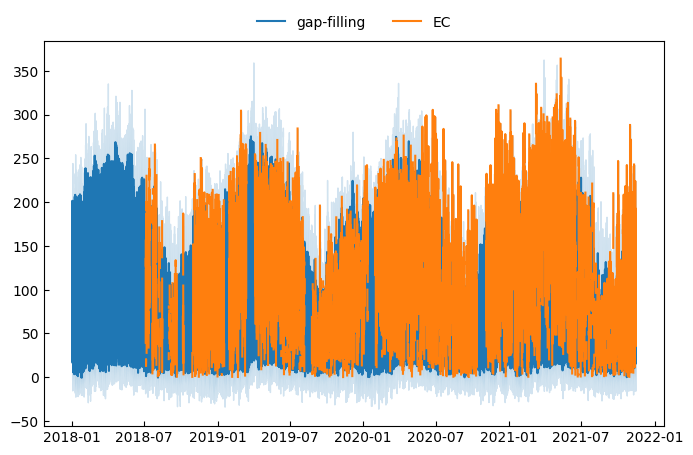

In [ ]:
p = df_path.loc['SN_NKR', 'path']
df_gapfill = pd.read_csv(p, index_col = 0)
df_gapfill.index = pd.to_datetime(df_gapfill.index, format = '%Y-%m-%d %H:%M:%S')
print(df_gapfill.index.year.unique())

# flux_name = 'co2_flux_µmol.m-2.s-1'
flux_name = 'sensible_heat_W/m²'
# flux_name =  'latent_heat_W/m²'
dfp = df_gapfill#.loc['2008', :]

fig, ax = setup_canvas(1, 1)
ensemble_members = ['pred_00', 'pred_01', 'pred_02', 'pred_03', 'pred_04', 'pred_05', 'pred_06', 'pred_07', 'pred_08', 'pred_09']
# pred_mean = dfp[ensemble_members].mean(axis = 1)
# pred_std = dfp[ensemble_members].std(axis = 1)

ax.plot(dfp[ensemble_members].mean(axis = 1), label = 'gap-filling')
ax.plot(dfp[flux_name], label = 'EC')
ax.fill_between(dfp.index, dfp.min(axis = 1), dfp.max(axis = 1), color = colors[0], alpha = 0.2)

upper_legend(ax)